In [1]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check the structure and data types
df.info()

# Check for number of rows and columns
df.shape

# Check for missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
# Convert the TotalCharges to numeric (fix incorrect data type)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove missing values
df = df.dropna()

# Check cleaned data
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [5]:
# Create churn flag (1 = churn, 0 = stay)
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Create tenure groups for cohort analysis
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 60],
    labels=['0-6 months', '6-12 months', '12-24 months', '24+ months']
)

# Preview dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-6 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,24+ months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-6 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,24+ months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-6 months


In [6]:
# Overall churn rate
churn_rate = df['Churn_Flag'].mean()

# Total customers
total_customers = df.shape[0]

# Customers who churned
churned_customers = df['Churn_Flag'].sum()

# Average tenure
avg_tenure = df['tenure'].mean()

# Average monthly charges
avg_monthly = df['MonthlyCharges'].mean()

# Revenue lost due to churn
revenue_lost = df[df['Churn_Flag'] == 1]['MonthlyCharges'].sum()

# Print results
print("Churn Rate:", churn_rate)
print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Average Tenure:", avg_tenure)
print("Average Monthly Charges:", avg_monthly)
print("Revenue Lost:", revenue_lost)

Churn Rate: 0.26578498293515357
Total Customers: 7032
Churned Customers: 1869
Average Tenure: 32.421786120591584
Average Monthly Charges: 64.79820819112628
Revenue Lost: 139130.85


In [7]:
# Overall churn rate
churn_rate = df['Churn_Flag'].mean()

# Total customers
total_customers = df.shape[0]

# Customers who churned
churned_customers = df['Churn_Flag'].sum()

# Average tenure
avg_tenure = df['tenure'].mean()

# Average monthly charges
avg_monthly = df['MonthlyCharges'].mean()

# Revenue lost due to churn
revenue_lost = df[df['Churn_Flag'] == 1]['MonthlyCharges'].sum()

# Print results
print("Churn Rate:", churn_rate)
print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Average Tenure:", avg_tenure)
print("Average Monthly Charges:", avg_monthly)
print("Revenue Lost:", revenue_lost)

Churn Rate: 0.26578498293515357
Total Customers: 7032
Churned Customers: 1869
Average Tenure: 32.421786120591584
Average Monthly Charges: 64.79820819112628
Revenue Lost: 139130.85


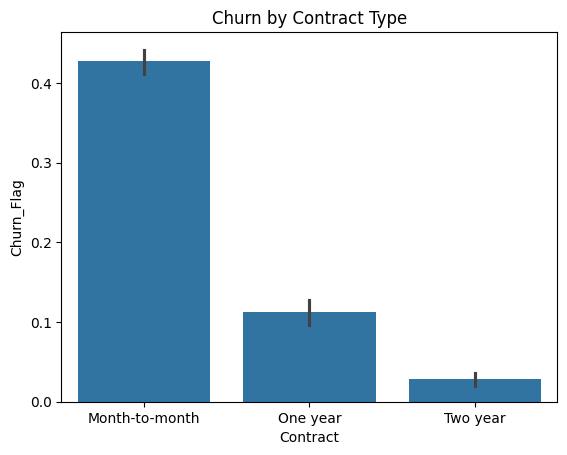

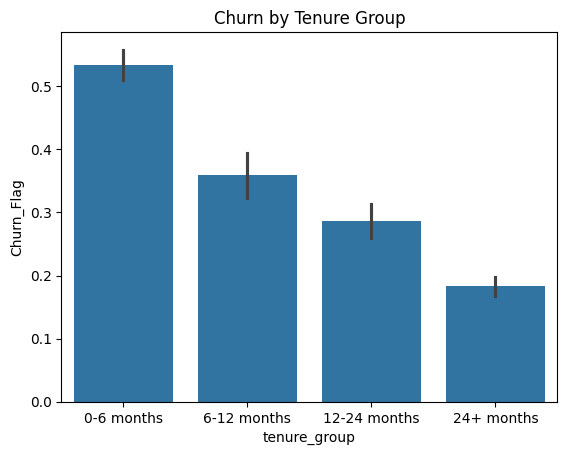

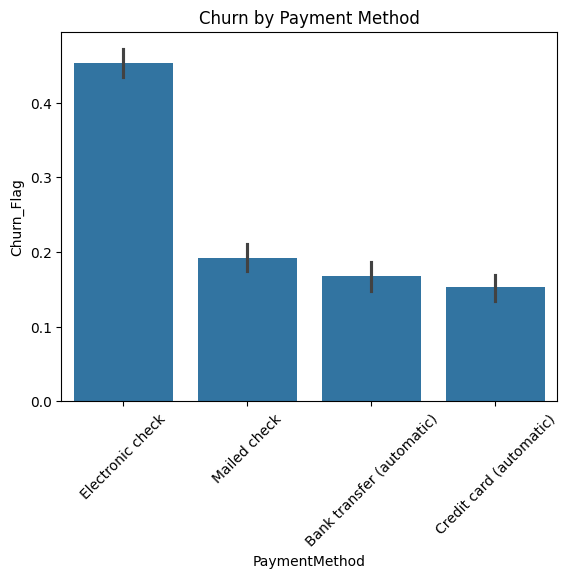

In [8]:
# Churn by contract type
sns.barplot(x='Contract', y='Churn_Flag', data=df)
plt.title('Churn by Contract Type')
plt.show()

# Churn by tenure group
sns.barplot(x='tenure_group', y='Churn_Flag', data=df)
plt.title('Churn by Tenure Group')
plt.show()

# Churn by payment method
sns.barplot(x='PaymentMethod', y='Churn_Flag', data=df)
plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()

In [9]:
# Average tenure for churned vs non-churned customers
df.groupby('Churn')['tenure'].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-6 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,24+ months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-6 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,24+ months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-6 months
